<a href="https://colab.research.google.com/github/rosnaaidiploma-web/Rosnaelizabeth/blob/main/task24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Model Performance ---
Accuracy Score: 0.77

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1416
           1       0.57      0.48      0.52       495

    accuracy                           0.77      1911
   macro avg       0.70      0.68      0.69      1911
weighted avg       0.76      0.77      0.77      1911



/tmp/ipykernel_364/3494445795.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cuisine_rating, x='Cuisines', y='Aggregate rating', palette='Set3')


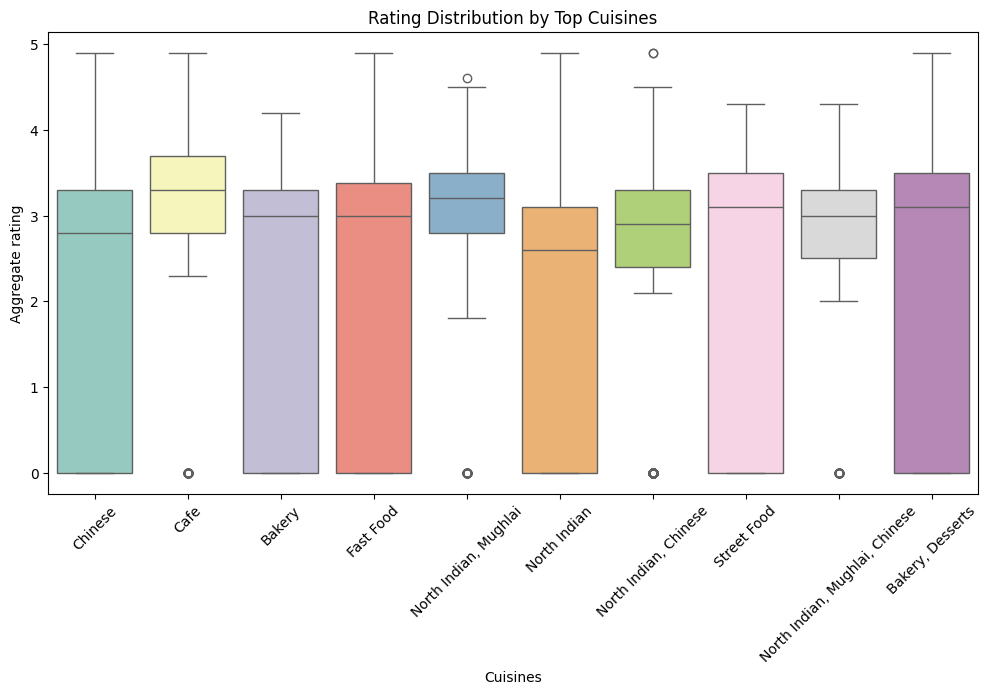

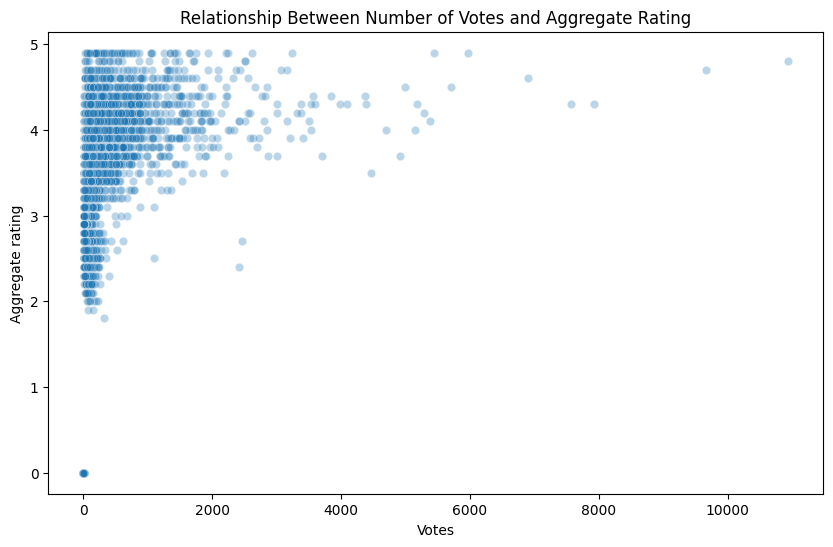

/tmp/ipykernel_364/3494445795.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='magma')


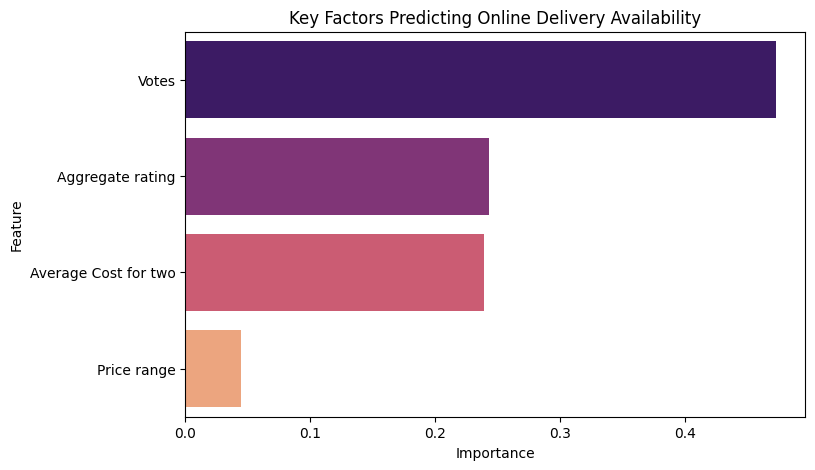

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Load the dataset
df = pd.read_csv('Dataset .csv')

# --- PREPROCESSING ---
# Selecting features that might influence delivery availability
# We use 'Price range', 'Aggregate rating', 'Votes', and 'Average Cost for two'
features = ['Price range', 'Aggregate rating', 'Votes', 'Average Cost for two']
target = 'Has Online delivery'

# Encoding the target variable (Yes/No to 1/0)
le = LabelEncoder()
df['delivery_encoded'] = le.fit_transform(df[target])

X = df[features]
y = df['delivery_encoded']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- TASK 1: Predictive Modeling (Random Forest) ---
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = model.predict(X_test)
print("--- Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- TASK 2: Customer Preference Analysis ---
# 1. Relationship between Cuisines and Ratings
# We'll look at the top 10 most frequent cuisines
top_cuisines = df['Cuisines'].value_counts().nlargest(10).index
cuisine_rating = df[df['Cuisines'].isin(top_cuisines)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=cuisine_rating, x='Cuisines', y='Aggregate rating', palette='Set3')
plt.title('Rating Distribution by Top Cuisines')
plt.xticks(rotation=45)
plt.show()

# 2. Impact of Votes on Rating
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Votes', y='Aggregate rating', alpha=0.3)
plt.title('Relationship Between Number of Votes and Aggregate Rating')
plt.show()

# 3. Feature Importance (What influences the model most?)
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Key Factors Predicting Online Delivery Availability')
plt.show()